---
title: "Practice Activity 8.2: Classification"
author: Lily
format:
    html:
        embed-resources: true
        code-line-numbers: true
---

**GitHub Repository**: <https://github.com/lilysteinberg/GSB-544---Computing-and-ML/tree/main/Week%207>

# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `species` using the other variables in the dataset.

**Dummify** all variables that require this.

In [27]:
### packages
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

# bonus
import matplotlib.pyplot as plt

In [28]:
### Penguin data
!pip install palmerpenguins
from palmerpenguins import load_penguins

In [29]:
### set up penguins df
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [30]:
### Drop other NAs
penguins = penguins.dropna()

In [ ]:
### specify x variables and y variable
X = penguins.drop(columns = ["species"])
y = penguins["species"]

### set up column transformers
cat_cols = ['island', 'sex']
num_cols = ['remainder__bill_length_mm', 'remainder__bill_depth_mm', 'remainder__flipper_length_mm', 'remainder__body_mass_g']

ct_dummies = ColumnTransformer([('dummify', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols)],
                               remainder = 'passthrough').set_output(transform="pandas")

ct_standardize = ColumnTransformer([('standardize', StandardScaler(), num_cols)],
                               remainder = 'passthrough').set_output(transform="pandas")

Let's use the other variables to predict `species`. Prepare your data and fit the following models on the entire dataset:

* Two kNN models (for different values of K)
* Two decision tree models (for different complexities of trees)

Compute the following, for each of your models, on test data. Keep in mind that you may need to stratify your creation of the training and test data.

* Confusion matrix
* Overall Accuracy
* Precision, Recall, AUC, and F1-score for each species

Create one ROC plot for the species of your choice.

# KNN

In [33]:
### KNN

# start by tuning to see best number of neighbors
knn_pipeline = Pipeline(
    [
     ("preprocessing1", ct_dummies),
     ("preprocessing2", ct_standardize),
     ("knn", KNeighborsClassifier())
    ],
).set_output(transform="pandas")

neighbors = {'knn__n_neighbors': np.arange(1, 11, 1)}

# addressing stratification
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

gscv = GridSearchCV(knn_pipeline, param_grid=neighbors, cv = cv, scoring='f1_macro')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.048294,0.018522,0.050391,0.020156,1,{'knn__n_neighbors': 1},0.982190,0.982005,0.982005,0.981806,0.962865,0.978174,0.007656,9
1,0.033932,0.014753,0.028011,0.015430,2,{'knn__n_neighbors': 2},0.963606,0.982005,0.982005,1.000000,0.962865,0.978096,0.013801,10
2,0.017366,0.003223,0.016844,0.003082,3,{'knn__n_neighbors': 3},0.982190,0.982005,1.000000,1.000000,0.962865,0.985412,0.013827,5
3,0.020419,0.000761,0.021821,0.003631,4,{'knn__n_neighbors': 4},0.963606,0.982005,1.000000,1.000000,0.962865,0.981695,0.016444,7
4,0.022947,0.005829,0.019912,0.001296,5,{'knn__n_neighbors': 5},0.982190,0.982005,1.000000,1.000000,0.962865,0.985412,0.013827,5
5,0.037986,0.008934,0.040570,0.010547,6,{'knn__n_neighbors': 6},0.963606,0.982005,1.000000,1.000000,0.962865,0.981695,0.016444,7
6,0.022467,0.002458,0.020794,0.001410,7,{'knn__n_neighbors': 7},0.963606,1.000000,1.000000,1.000000,0.981806,0.989083,0.014557,1
7,0.021039,0.001938,0.023695,0.006159,8,{'knn__n_neighbors': 8},0.963606,1.000000,1.000000,1.000000,0.981806,0.989083,0.014557,1
8,0.035207,0.009702,0.033905,0.009593,9,{'knn__n_neighbors': 9},0.963606,1.000000,1.000000,1.000000,0.981806,0.989083,0.014557,1
9,0.043230,0.010565,0.034377,0.010228,10,{'knn__n_neighbors': 10},0.963606,1.000000,1.000000,1.000000,0.981806,0.989083,0.014557,1


In [34]:
# make pipeline for neighbors = 7
knn_first_pipeline = Pipeline(
  [
   ("preprocessing1", ct_dummies),
   ("preprocessing2", ct_standardize),
   ("knn", KNeighborsClassifier(n_neighbors = 7))
  ]
).set_output(transform="pandas")

# fit
knn_first_pipeline_fitted = knn_first_pipeline.fit(X, y)

In [35]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(knn_first_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[145   1   0]
 [  2  66   0]
 [  0   0 119]]
              precision    recall  f1-score   support

      Adelie       0.99      0.99      0.99       146
   Chinstrap       0.99      0.97      0.98        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           0.99       333
   macro avg       0.99      0.99      0.99       333
weighted avg       0.99      0.99      0.99       333



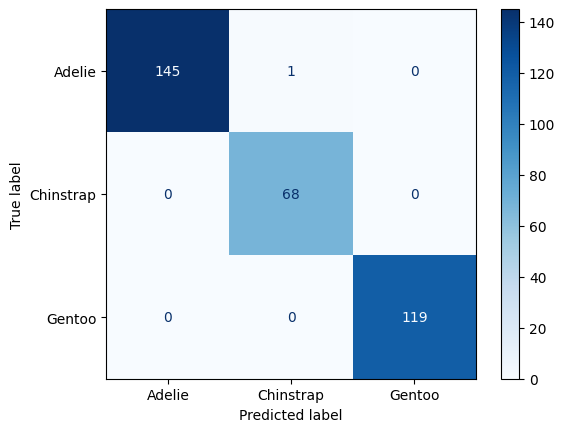

In [36]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(knn_first_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

In [37]:
# make pipeline for neighbors = 3
knn_second_pipeline = Pipeline(
  [
   ("preprocessing1", ct_dummies),
   ("preprocessing2", ct_standardize),
   ("knn", KNeighborsClassifier(n_neighbors = 3))
  ]
).set_output(transform="pandas")

# fit
knn_second_pipeline_fitted = knn_first_pipeline.fit(X, y)

In [38]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(knn_second_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[145   1   0]
 [  3  65   0]
 [  0   0 119]]
              precision    recall  f1-score   support

      Adelie       0.98      0.99      0.99       146
   Chinstrap       0.98      0.96      0.97        68
      Gentoo       1.00      1.00      1.00       119

    accuracy                           0.99       333
   macro avg       0.99      0.98      0.99       333
weighted avg       0.99      0.99      0.99       333



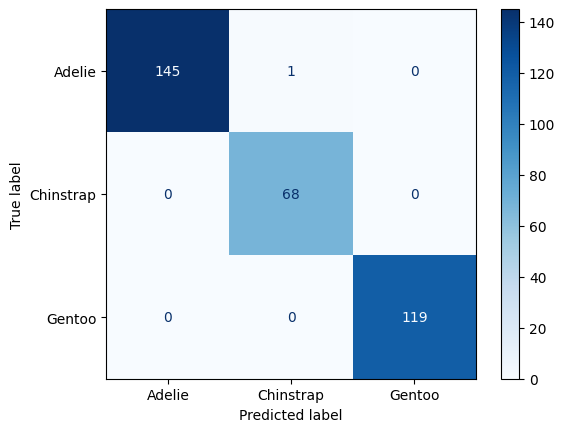

In [39]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(knn_second_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

# Decision Tree

In [ ]:
### Decision Tree
# start by tuning to see best ccp_alpha
dt_pipeline = Pipeline(
    [
     ("preprocessing1", ct_dummies),
     ("dt", DecisionTreeClassifier())
    ],
).set_output(transform="pandas")

tuning = {'dt__ccp_alpha': np.arange(0, 1, 0.1)}

# addressing stratification
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

gscv = GridSearchCV(dt_pipeline, param_grid=tuning, cv = cv, scoring='f1_macro')

# feed in data
gscv_fitted = gscv.fit(X, y)
gscv_fitted.cv_results_

# view results
df_cv_results_ = pd.DataFrame(gscv_fitted.cv_results_)
df_cv_results_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_dt__ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015784,0.002059,0.014858,0.002590,0.0,{'dt__ccp_alpha': 0.0},0.963606,0.969357,0.949560,0.987258,0.962865,0.966529,0.012228,1
1,0.015000,0.001241,0.013158,0.001185,0.1,{'dt__ccp_alpha': 0.1},0.923473,0.895699,0.963540,0.927485,0.943051,0.930649,0.022444,2
2,0.029472,0.006438,0.033837,0.010153,0.2,{'dt__ccp_alpha': 0.2},0.923473,0.895699,0.963540,0.927485,0.943051,0.930649,0.022444,2
3,0.033486,0.012358,0.026682,0.005604,0.3,{'dt__ccp_alpha': 0.30000000000000004},0.589111,0.586667,0.598831,0.577198,0.605634,0.591488,0.009870,4
4,0.025231,0.006852,0.030119,0.022516,0.4,{'dt__ccp_alpha': 0.4},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5
5,0.040002,0.010536,0.037195,0.014839,0.5,{'dt__ccp_alpha': 0.5},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5
6,0.037853,0.014950,0.033332,0.017056,0.6,{'dt__ccp_alpha': 0.6000000000000001},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5
7,0.037577,0.025790,0.031557,0.018542,0.7,{'dt__ccp_alpha': 0.7000000000000001},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5
8,0.052407,0.009043,0.053350,0.023193,0.8,{'dt__ccp_alpha': 0.8},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5
9,0.034433,0.012845,0.034637,0.012815,0.9,{'dt__ccp_alpha': 0.9},0.206186,0.201389,0.201389,0.203509,0.203509,0.203196,0.001770,5


In [41]:
# make pipeline for max depth = 10
dt_first_pipeline = Pipeline(
  [
    ("preprocessing1", ct_dummies),
    ("dt", DecisionTreeClassifier(ccp_alpha=0, max_depth=10))
  ]
).set_output(transform="pandas")

# fit
dt_first_pipeline_fitted = dt_first_pipeline.fit(X, y)

In [42]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(dt_first_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[142   4   0]
 [  2  66   0]
 [  1   0 118]]
              precision    recall  f1-score   support

      Adelie       0.98      0.97      0.98       146
   Chinstrap       0.94      0.97      0.96        68
      Gentoo       1.00      0.99      1.00       119

    accuracy                           0.98       333
   macro avg       0.97      0.98      0.98       333
weighted avg       0.98      0.98      0.98       333



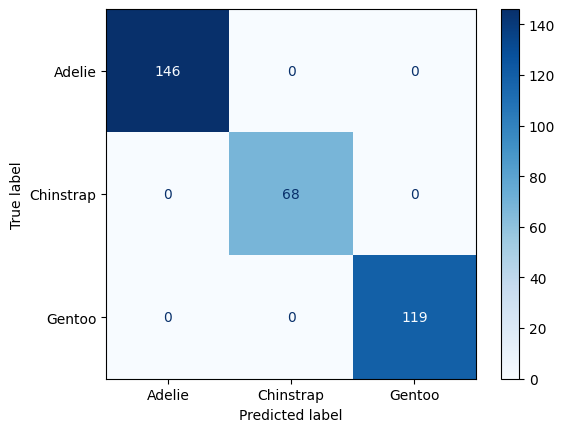

In [43]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(dt_first_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

In [44]:
# make pipeline for max depth = 1
dt_second_pipeline = Pipeline(
  [
    ("preprocessing1", ct_dummies),
    ("decision_tree", DecisionTreeClassifier(ccp_alpha=0, max_depth=1))
  ]
).set_output(transform="pandas")

# fit
dt_second_pipeline_fitted = dt_second_pipeline.fit(X, y)

In [45]:
# classification report for accuracy, precision, recall, f1
y_pred = cross_val_predict(dt_second_pipeline, X, y, cv=cv)
print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

[[144   0   2]
 [ 63   0   5]
 [  2   0 117]]
              precision    recall  f1-score   support

      Adelie       0.69      0.99      0.81       146
   Chinstrap       0.00      0.00      0.00        68
      Gentoo       0.94      0.98      0.96       119

    accuracy                           0.78       333
   macro avg       0.54      0.66      0.59       333
weighted avg       0.64      0.78      0.70       333



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


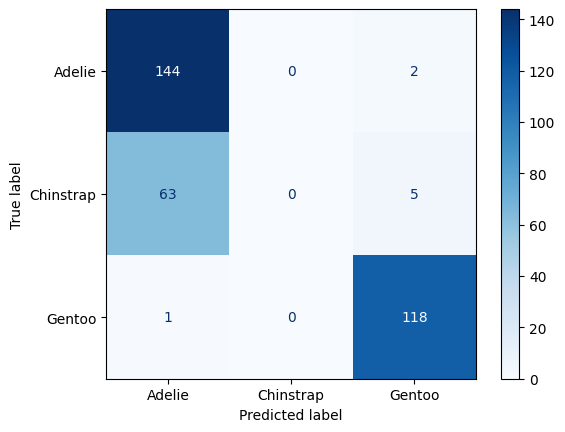

In [46]:
# optional to make the confusion matrix look better. results are the same either way
ConfusionMatrixDisplay.from_estimator(dt_second_pipeline_fitted,
                                      X,
                                      y,
                                      cmap = plt.cm.Blues);

# ROC Curve -- Gentoo Species

In [53]:
# Adjusting data so binary for species Gentoo
penguins["species_Gentoo"] = (penguins["species"] == "Gentoo").astype(int)

# specify new y variable
y = penguins["species_Gentoo"]

# make pipeline for max depth = 1
dt_binary_pipeline = Pipeline(
  [
    ("preprocessing1", ct_dummies),
    ("decision_tree", DecisionTreeClassifier(ccp_alpha=0, max_depth=1))
  ]
).set_output(transform="pandas")

# fit
dt_binary_pipeline_fitted = dt_second_pipeline.fit(X, y)

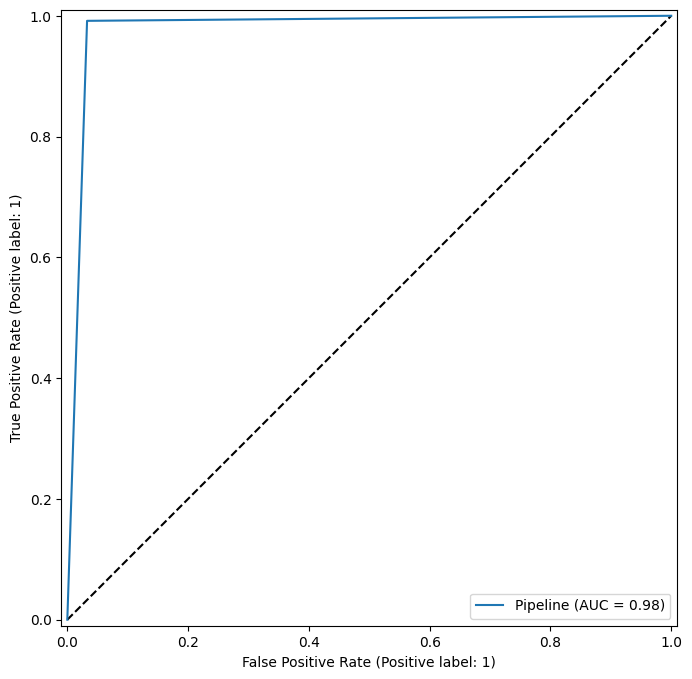

In [55]:
### ROC curve for second decision tree (max_depth = 1)

fig, ax = plt.subplots(figsize = (8, 8))

ax.plot(ax.get_xlim(), ax.get_ylim(), ls = '--', c = 'k')
RocCurveDisplay.from_estimator(dt_binary_pipeline_fitted,
                               X = X,
                               y = y,
                               ax = ax);

In [56]:
y_score = dt_binary_pipeline_fitted.predict_proba(X)[:, 1]
roc_auc_score(y, y_score)

np.float64(0.9794431791408152)